# Prior UQ plot

This notebook mirrors `scripts/plot_bar1d_prior_uq.py`.

It loads a single `.npz` result file, builds the four-panel prior-UQ figure, and optionally saves the figure into `results/`.

In [7]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde


In [8]:
def setup_mpl() -> None:
    mpl.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "STIXGeneral"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 16,
        "axes.titlesize": 14,
        "font.size": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.edgecolor": "black",
        "legend.framealpha": 1.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def ecdf(samples: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(np.asarray(samples, dtype=float))
    n = x.size
    y = np.arange(1, n + 1, dtype=float) / n
    return x, y


def kde_pdf(samples: np.ndarray, x_grid: np.ndarray, bw_method: float | None = None) -> np.ndarray:
    kde = gaussian_kde(np.asarray(samples, dtype=float), bw_method=bw_method)
    return np.asarray(kde(x_grid), dtype=float)


In [ ]:
setup_mpl()

input_path = Path("results/case_7.npz")
if not input_path.exists():
    input_path = Path("results/case_7.ipynb.npz")

if not input_path.exists():
    raise FileNotFoundError("Create a case result first with notebooks/01_bar1d_full_pipeline.ipynb or scripts/run_bar1d_full_pipeline.py")

save_figure = False
output_path = Path("results/bar1d_prior_uq_notebook.png")

data = np.load(input_path)
x = np.asarray(data["node_coordinates"], dtype=float)
mu = np.asarray(data["pce_mean"], dtype=float)
cov = np.asarray(data["pce_covariance"], dtype=float)
std = np.sqrt(np.maximum(np.diag(cov), 0.0))
ci95 = 1.96 * std
mc_tip = np.asarray(data["mc_tip_samples"], dtype=float)
pce_tip = np.asarray(data["pce_tip_samples"], dtype=float)

tip_min = min(mc_tip.min(), pce_tip.min())
tip_max = max(mc_tip.max(), pce_tip.max())
pad = 0.1 * max(tip_max - tip_min, 1e-12)
x_pdf = np.linspace(
    tip_min - pad,
    tip_max + pad,
    500,
)
y_mc_kde = kde_pdf(mc_tip, x_pdf)
y_pce_kde = kde_pdf(pce_tip, x_pdf)
x_mc_cdf, y_mc_cdf = ecdf(mc_tip)
x_pc_cdf, y_pc_cdf = ecdf(pce_tip)


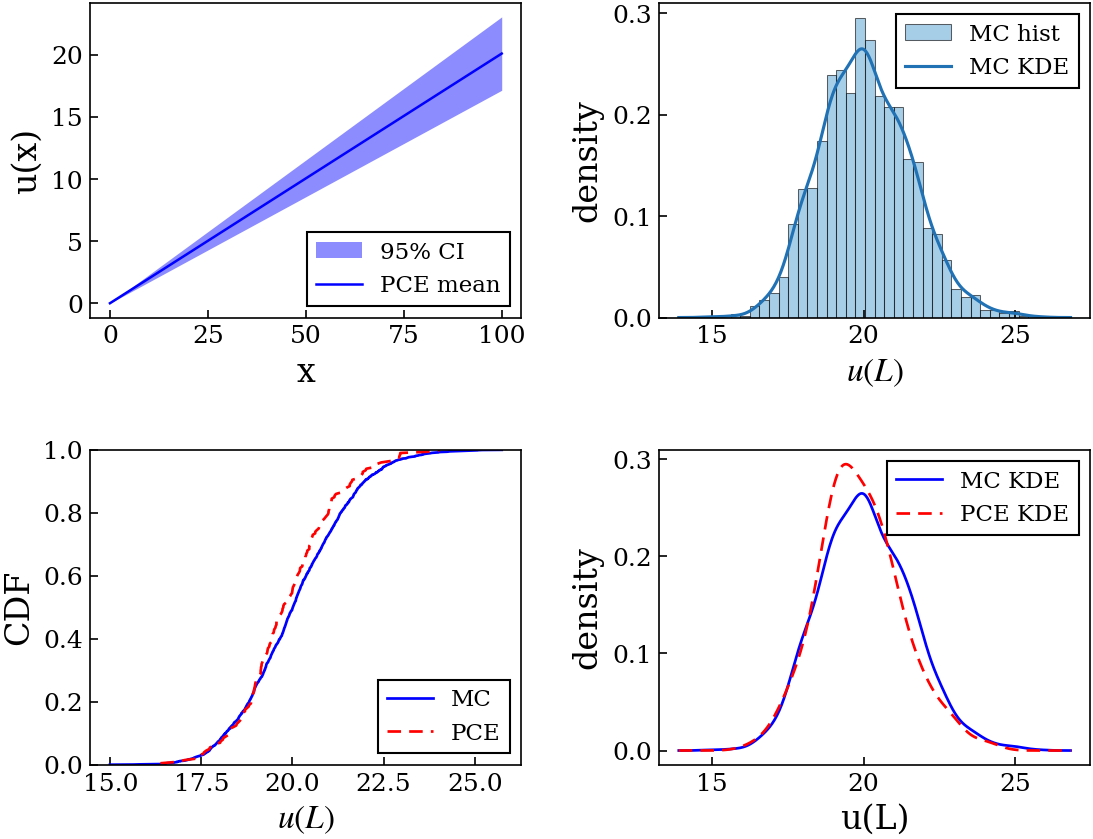

In [10]:
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(8.6, 6.6))
ax1, ax2, ax3, ax4 = axes.flat

ax1.fill_between(x, mu - ci95, mu + ci95, color="blue", alpha=0.45, linewidth=0.0, label="95% CI")
ax1.plot(x, mu, color="blue", linewidth=1.2, label="PCE mean")
ax1.set_xlabel("x")
ax1.set_ylabel("u(x)")
ax1.legend(loc="lower right")

ax2.hist(mc_tip, bins=34, density=True, color="#6baed6", edgecolor="black", linewidth=0.5, alpha=0.6, label="MC hist")
ax2.plot(x_pdf, y_mc_kde, color="#2171b5", linewidth=1.5, label="MC KDE")
# ax2.plot(x_pdf, y_pce_kde, color="#cb181d", linewidth=1.5, linestyle=(0, (5, 3)), label="PCE KDE")
ax2.set_xlabel("$u(L)$")
ax2.set_ylabel("density")
ax2.legend(loc="upper right")

ax3.plot(x_mc_cdf, y_mc_cdf, color="blue", linewidth=1.3, label="MC")
ax3.plot(x_pc_cdf, y_pc_cdf, color="red", linewidth=1.3, linestyle=(0, (5, 3)), label="PCE")
ax3.set_xlabel("$u(L)$")
ax3.set_ylabel("CDF")
ax3.set_ylim(0.0, 1.0)
ax3.legend(loc="lower right")

ax4.plot(x_pdf, y_mc_kde, color="blue", linewidth=1.3, label="MC KDE")
ax4.plot(x_pdf, y_pce_kde, color="red", linewidth=1.3, linestyle=(0, (5, 3)), label="PCE KDE")
ax4.set_xlabel("u(L)")
ax4.set_ylabel("density")
ax4.legend(loc="upper right")

for ax in axes.flat:
    ax.tick_params(direction="in")
    ax.grid(False)

fig.subplots_adjust(wspace=0.32, hspace=0.42)

if save_figure:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path)
    print(f"saved {output_path}")

plt.show()
